In [1]:
import numpy as np
import pandas as pd
import glob
import os
import regex as re
import matplotlib.pyplot as plt

In [2]:
treated_malaria_df =  pd.read_csv("../../data_files/data/sivep_notification_data/treated_malaria_notification_data/malaria_vivax_treated.csv")
treated_malaria_df

,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME
0,2003-01-27,05/2003,21,210290,21.0,210055.0,29.0,1,2003-01-25,99.0,21.0,210055.0,29.0,2003-01-27
1,2003-03-20,12/2003,21,210232,21.0,210232.0,NaN,1,2003-03-18,11.0,21.0,210203.0,41.0,2003-03-20
2,2003-01-27,05/2003,21,210232,21.0,210203.0,55.0,1,2003-01-26,1.0,21.0,210203.0,55.0,2003-01-27
3,2003-09-30,40/2003,21,210232,21.0,210203.0,88.0,1,2003-09-26,1.0,21.0,210203.0,88.0,2003-09-30
4,2003-10-09,37/2003,21,210232,21.0,210203.0,88.0,1,2003-09-09,11.0,21.0,210203.0,88.0,2003-10-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3586495,2023-09-21,38/2023,21,210177,21.0,210177.0,5.0,1,2023-09-20,5.0,15.0,150360.0,NaN,2023-09-21
3586496,2023-10-13,41/2023,12,120045,13.0,130070.0,NaN,1,2023-11-01,7.0,13.0,130070.0,NaN,2023-10-13
3586497,2023-10-25,43/2023,14,140015,14.0,140010.0,1148.0,1,2023-10-23,2.0,14.0,140005.0,NaN,2023-10-25
3586498,2023-09-29,39/2023,16,160060,16.0,160060.0,32.0,1,2023-09-26,11.0,16.0,160027.0,NaN,2023-09-29


In [3]:
manaus_malaria_data = treated_malaria_df[treated_malaria_df['MUN_RESI'] == 130260.0]
manaus_malaria_data

,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME
6,2003-10-13,42/2003,13,130260,13.0,130260.0,564.0,1,2003-11-10,11.0,13.0,130260.0,564.0,2003-10-13
7,2003-10-10,41/2003,13,130260,13.0,130260.0,564.0,1,2003-10-10,11.0,13.0,130260.0,564.0,2003-10-10
8,2003-10-10,41/2003,13,130260,13.0,130260.0,564.0,1,2003-10-10,11.0,13.0,130260.0,564.0,2003-10-10
9,2003-03-25,13/2003,13,130260,13.0,130260.0,564.0,1,2003-03-22,99.0,13.0,130260.0,564.0,2003-03-25
10,2003-07-11,45/2003,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-07-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3586187,2023-05-30,22/2023,13,130260,13.0,130260.0,833.0,1,2023-05-26,10.0,11.0,110020.0,NaN,2023-05-30
3586214,2023-12-22,51/2023,11,110020,13.0,130260.0,NaN,1,2023-12-18,4.0,13.0,130260.0,NaN,2023-12-22
3586363,2023-12-26,52/2023,13,130260,13.0,130260.0,5.0,1,2023-12-23,11.0,14.0,140023.0,NaN,2023-12-26
3586380,2023-07-31,31/2023,13,130260,13.0,130260.0,222.0,1,2023-07-25,5.0,13.0,130406.0,NaN,2023-07-31


In [4]:
test = manaus_malaria_data[manaus_malaria_data['SINTOMAS'] == 2]
test

,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME
10,2003-07-11,45/2003,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-07-11
19,2003-11-24,48/2003,13,130260,13.0,130260.0,564.0,2,NaN,1.0,13.0,130260.0,564.0,2003-11-24
20,2003-12-12,50/2003,13,130260,13.0,130260.0,564.0,2,NaN,1.0,13.0,130260.0,564.0,2003-12-12
37,2003-10-11,46/2003,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-10-11
38,2003-09-23,38/3,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-09-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3584925,2023-04-08,31/2023,13,130260,13.0,130260.0,1077.0,2,NaN,11.0,13.0,130260.0,1077.0,2023-04-08
3584926,2023-10-11,45/2023,13,130260,13.0,130260.0,1077.0,2,NaN,11.0,13.0,130260.0,1077.0,2023-10-11
3584928,2023-10-11,45/2023,13,130260,13.0,130260.0,1077.0,2,NaN,1.0,13.0,130260.0,1077.0,2023-10-11
3584929,2023-10-20,42/2023,13,130260,13.0,130260.0,1077.0,2,NaN,11.0,13.0,130260.0,1077.0,2023-10-20


In [5]:
# Asymptomatic patients
asymptomatic_df = manaus_malaria_data[manaus_malaria_data['SINTOMAS'] == 2]

# Check for inconsistent rows:
# asymptomatic but symptom date exists
inconsistent_asymptomatic = asymptomatic_df[
    asymptomatic_df['DT_SINTO'].notna()
]

print("Number of inconsistent asymptomatic records:")
print(len(inconsistent_asymptomatic))

inconsistent_asymptomatic

Number of inconsistent asymptomatic records:
0


,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME


In [6]:
def aggregate_with_infectious_period(df, infectious_days=120):
    """
    Aggregate cases considering infectious period.
    Handles both symptomatic (DT_SINTO available) and asymptomatic cases.
    
    For asymptomatic cases (SINTOMAS = 2), we use DT_NOTIF as the infection start date.
    For symptomatic cases (SINTOMAS = 1), we use DT_SINTO.
    """
    
    # Make a copy
    df = df.copy()
    
    # Create a unified infection start date column
    # For symptomatic cases (SINTOMAS = 1): use DT_SINTO
    # For asymptomatic cases (SINTOMAS = 2): use DT_NOTIF
    # For other cases: use DT_NOTIF as fallback
    df['infection_start'] = df['DT_SINTO'].copy()
    
    # For asymptomatic or missing symptom date, use notification date
    asymptomatic_mask = (df['SINTOMAS'] == 2) | (df['DT_SINTO'].isna())
    df.loc[asymptomatic_mask, 'infection_start'] = df.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Ensure datetime format for infection_start
    if df['infection_start'].dtype != 'datetime64[ns]':
        df['infection_start'] = pd.to_datetime(df['infection_start'], errors='coerce')
    
    # Drop only rows where infection_start is completely invalid (should be rare)
    df = df.dropna(subset=['infection_start'])
    
    print(f"Processing {len(df):,} cases")
    print(f"  - Symptomatic (using DT_SINTO): {(df['SINTOMAS'] == 1).sum():,}")
    print(f"  - Asymptomatic (using DT_NOTIF): {(df['SINTOMAS'] == 2).sum():,}")
    print(f"  - Other/Unknown: {((df['SINTOMAS'] != 1) & (df['SINTOMAS'] != 2)).sum():,}")
    
    # Create date range covering the entire period
    min_date = df['infection_start'].min()
    max_date = df['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    print(f"Date range: {min_date.date()} to {max_date.date()} ({len(date_range):,} days)")
    
    # Convert to numpy arrays for faster operations
    start_dates = df['infection_start'].values
    end_dates = start_dates + np.timedelta64(infectious_days, 'D')
    
    # Initialize array for active cases
    active_cases = np.zeros(len(date_range), dtype=int)
    
    # Process cases to count active days
    print("Calculating active cases...")
    for start, end in zip(start_dates, end_dates):
        mask = (date_range >= start) & (date_range < end)
        active_cases[mask] += 1
    
    # Create result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_cases': active_cases
    })
    
    print(f"Peak active cases: {active_cases.max():,}")
    print(f"Average active cases: {active_cases.mean():.1f}")
    
    return result_df

# Apply to your cleaned data
daily_active_cases = aggregate_with_infectious_period(manaus_malaria_data)

Processing 331,470 cases
  - Symptomatic (using DT_SINTO): 307,597
  - Asymptomatic (using DT_NOTIF): 23,873
  - Other/Unknown: 0
Date range: 2002-12-27 to 2024-04-27 (7,793 days)
Calculating active cases...
Peak active cases: 18,789
Average active cases: 5104.1


In [7]:
def aggregate_with_infectious_period_detailed(df, infectious_days=120):
    """
    Detailed aggregation tracking symptomatic and asymptomatic cases separately.
    """
    
    # Make a copy
    df = df.copy()
    
    # Ensure datetime for date columns
    date_columns = ['DT_SINTO', 'DT_NOTIF']
    for col in date_columns:
        if col in df.columns and df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Create infection start date based on symptomatology
    df['infection_start'] = df['DT_SINTO'].copy()
    asymptomatic_mask = (df['SINTOMAS'] == 2) | (df['DT_SINTO'].isna())
    df.loc[asymptomatic_mask, 'infection_start'] = df.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Drop only completely invalid rows
    df = df.dropna(subset=['infection_start'])
    
    # Separate symptomatic and asymptomatic
    symptomatic_df = df[df['SINTOMAS'] == 1].copy()
    asymptomatic_df = df[df['SINTOMAS'] == 2].copy()
    
    print(f"Total cases: {len(df):,}")
    print(f"  - Symptomatic: {len(symptomatic_df):,}")
    print(f"  - Asymptomatic: {len(asymptomatic_df):,}")
    
    # Create date range
    min_date = df['infection_start'].min()
    max_date = df['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    # Function to count active cases for a subset
    def count_active(subset_df):
        if len(subset_df) == 0:
            return np.zeros(len(date_range), dtype=int)
        
        start_dates = subset_df['infection_start'].values
        end_dates = start_dates + np.timedelta64(infectious_days, 'D')
        active = np.zeros(len(date_range), dtype=int)
        
        for start, end in zip(start_dates, end_dates):
            mask = (date_range >= start) & (date_range < end)
            active[mask] += 1
        
        return active
    
    # Count active cases for each group
    print("Calculating active cases...")
    active_symptomatic = count_active(symptomatic_df)
    active_asymptomatic = count_active(asymptomatic_df)
    active_total = active_symptomatic + active_asymptomatic
    
    # Create detailed result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_total': active_total,
        'active_symptomatic': active_symptomatic,
        'active_asymptomatic': active_asymptomatic
    })
    
    print(f"\nResults:")
    print(f"  Peak total active: {active_total.max():,}")
    print(f"  Peak symptomatic: {active_symptomatic.max():,}")
    print(f"  Peak asymptomatic: {active_asymptomatic.max():,}")
    
    return result_df

# Apply detailed version
daily_active_cases_detailed = aggregate_with_infectious_period_detailed(manaus_malaria_data)

Total cases: 331,470
  - Symptomatic: 307,597
  - Asymptomatic: 23,873
Calculating active cases...

Results:
  Peak total active: 18,789
  Peak symptomatic: 17,839
  Peak asymptomatic: 1,684


Original data range: 2002-12-27 00:00:00 to 2024-04-27 00:00:00
Trimmed data range: 2003-04-26 00:00:00 to 2024-04-27 00:00:00
Rows removed: 120
Remaining rows: 7,673


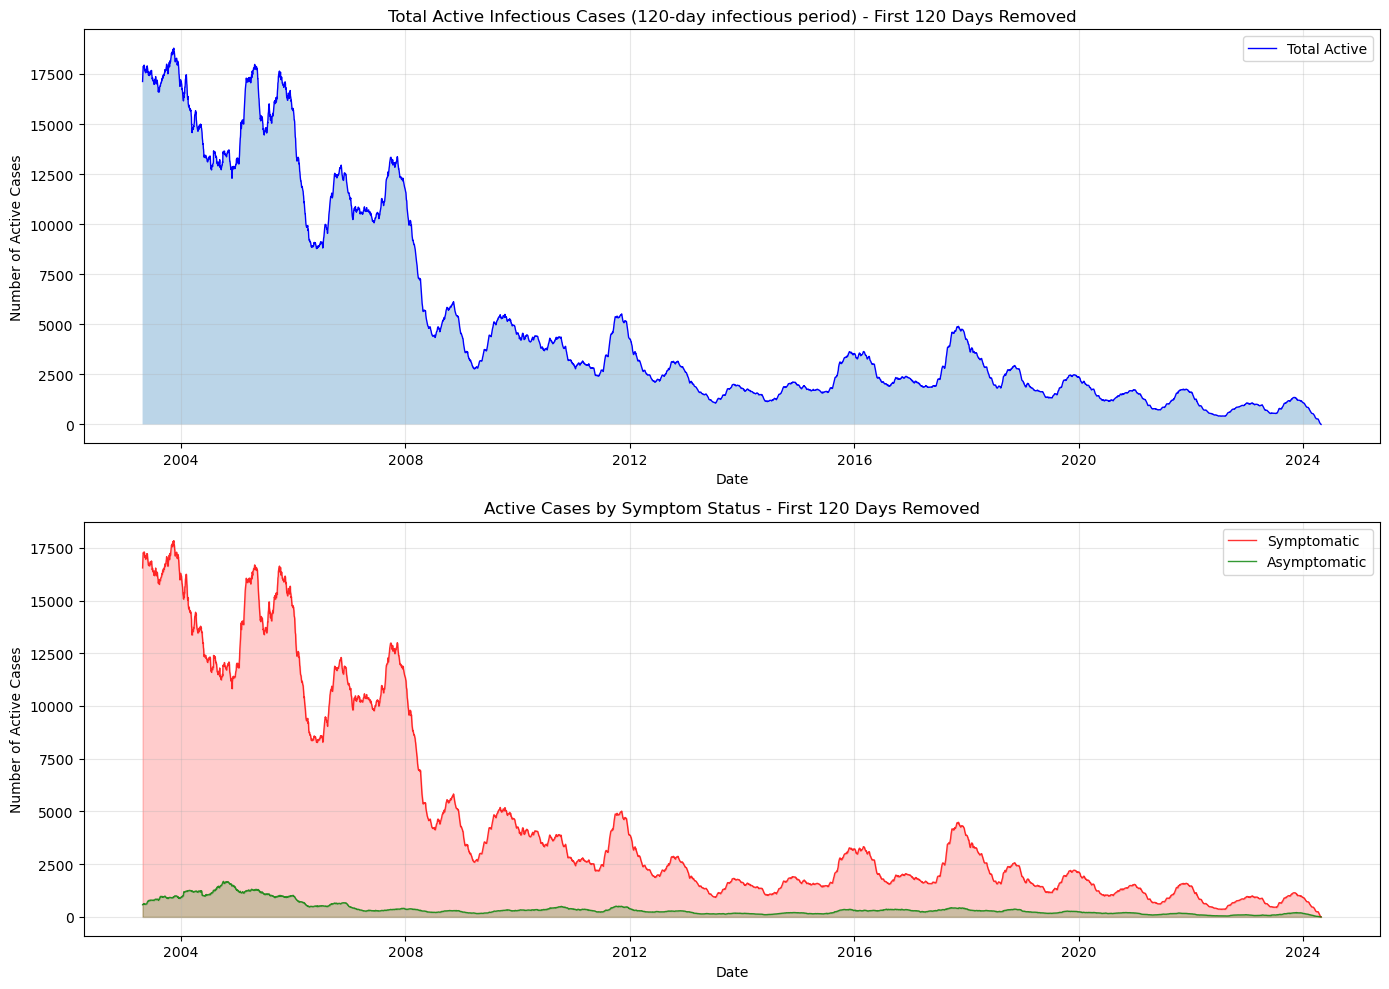


=== SUMMARY STATISTICS (First 120 Days Removed) ===
Period: 2003-04-26 to 2024-04-27

Active Cases Statistics (trimmed):
  Average daily active: 5067
  Peak daily active: 18,789
  Peak date: 2003-11-15


In [8]:
# After creating daily_active_cases_detailed, drop the first 120 days

# Remove the first 120 days to eliminate the artificial ramp-up period
daily_active_cases_detailed_trimmed = daily_active_cases_detailed.iloc[120:].reset_index(drop=True)

print(f"Original data range: {daily_active_cases_detailed['date'].min()} to {daily_active_cases_detailed['date'].max()}")
print(f"Trimmed data range: {daily_active_cases_detailed_trimmed['date'].min()} to {daily_active_cases_detailed_trimmed['date'].max()}")
print(f"Rows removed: 120")
print(f"Remaining rows: {len(daily_active_cases_detailed_trimmed):,}")

# Plot the trimmed results
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot total active cases (trimmed)
axes[0].plot(daily_active_cases_detailed_trimmed['date'], 
             daily_active_cases_detailed_trimmed['active_total'], 
             color='blue', linewidth=1, label='Total Active')
axes[0].fill_between(daily_active_cases_detailed_trimmed['date'], 0, 
                     daily_active_cases_detailed_trimmed['active_total'], alpha=0.3)
axes[0].set_title('Total Active Infectious Cases (120-day infectious period) - First 120 Days Removed')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Active Cases')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot symptomatic vs asymptomatic (trimmed)
axes[1].plot(daily_active_cases_detailed_trimmed['date'], 
             daily_active_cases_detailed_trimmed['active_symptomatic'], 
             color='red', linewidth=1, label='Symptomatic', alpha=0.8)
axes[1].plot(daily_active_cases_detailed_trimmed['date'], 
             daily_active_cases_detailed_trimmed['active_asymptomatic'], 
             color='green', linewidth=1, label='Asymptomatic', alpha=0.8)
axes[1].fill_between(daily_active_cases_detailed_trimmed['date'], 0, 
                     daily_active_cases_detailed_trimmed['active_symptomatic'], 
                     color='red', alpha=0.2)
axes[1].fill_between(daily_active_cases_detailed_trimmed['date'], 0, 
                     daily_active_cases_detailed_trimmed['active_asymptomatic'], 
                     color='green', alpha=0.2)
axes[1].set_title('Active Cases by Symptom Status - First 120 Days Removed')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Active Cases')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics for trimmed data
print("\n=== SUMMARY STATISTICS (First 120 Days Removed) ===")
print(f"Period: {daily_active_cases_detailed_trimmed['date'].min().date()} to {daily_active_cases_detailed_trimmed['date'].max().date()}")
print(f"\nActive Cases Statistics (trimmed):")
print(f"  Average daily active: {daily_active_cases_detailed_trimmed['active_total'].mean():.0f}")
print(f"  Peak daily active: {daily_active_cases_detailed_trimmed['active_total'].max():,}")
print(f"  Peak date: {daily_active_cases_detailed_trimmed.loc[daily_active_cases_detailed_trimmed['active_total'].idxmax(), 'date'].date()}")

In [9]:
def aggregate_with_infectious_period_and_carryover(df, infectious_days=120, start_year=2016, end_year=2024):
    """
    Aggregate cases considering infectious period, including carryover from previous year.
    Handles both symptomatic and asymptomatic cases.
    """
    
    # Make a copy
    df = df.copy()
    
    # Ensure datetime for date columns
    date_columns = ['DT_SINTO', 'DT_NOTIF']
    for col in date_columns:
        if col in df.columns and df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Include previous year for carryover calculation
    df_extended = df[(df['DT_NOTIF'].dt.year >= start_year - 1) & 
                     (df['DT_NOTIF'].dt.year <= end_year)].copy()
    
    print(f"\n=== Processing {start_year}-{end_year} Data (with carryover from {start_year-1}) ===")
    print(f"Total cases in extended range: {len(df_extended):,}")
    
    # Create a unified infection start date column
    df_extended['infection_start'] = df_extended['DT_SINTO'].copy()
    
    # For asymptomatic or missing symptom date, use notification date
    asymptomatic_mask = (df_extended['SINTOMAS'] == 2) | (df_extended['DT_SINTO'].isna())
    df_extended.loc[asymptomatic_mask, 'infection_start'] = df_extended.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Ensure datetime format for infection_start
    if df_extended['infection_start'].dtype != 'datetime64[ns]':
        df_extended['infection_start'] = pd.to_datetime(df_extended['infection_start'], errors='coerce')
    
    # Drop only rows where infection_start is completely invalid
    df_extended = df_extended.dropna(subset=['infection_start'])
    
    print(f"Valid cases after processing: {len(df_extended):,}")
    print(f"  - Symptomatic (using DT_SINTO): {(df_extended['SINTOMAS'] == 1).sum():,}")
    print(f"  - Asymptomatic (using DT_NOTIF): {(df_extended['SINTOMAS'] == 2).sum():,}")
    
    # Create date range covering the entire period
    min_date = df_extended['infection_start'].min()
    max_date = df_extended['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    print(f"\nDate range: {min_date.date()} to {max_date.date()} ({len(date_range):,} days)")
    
    # Separate symptomatic and asymptomatic
    symptomatic_df = df_extended[df_extended['SINTOMAS'] == 1].copy()
    asymptomatic_df = df_extended[df_extended['SINTOMAS'] == 2].copy()
    
    # Function to count active cases for a subset
    def count_active(subset_df):
        if len(subset_df) == 0:
            return np.zeros(len(date_range), dtype=int)
        
        start_dates = subset_df['infection_start'].values
        end_dates = start_dates + np.timedelta64(infectious_days, 'D')
        active = np.zeros(len(date_range), dtype=int)
        
        for start, end in zip(start_dates, end_dates):
            mask = (date_range >= start) & (date_range < end)
            active[mask] += 1
        
        return active
    
    # Count active cases for each group
    print("\nCalculating active cases...")
    active_symptomatic = count_active(symptomatic_df)
    active_asymptomatic = count_active(asymptomatic_df)
    active_total = active_symptomatic + active_asymptomatic
    
    # Create detailed result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_total': active_total,
        'active_symptomatic': active_symptomatic,
        'active_asymptomatic': active_asymptomatic
    })
    
    # Filter to only show results from start_year onward
    result_df_filtered = result_df[result_df['date'].dt.year >= start_year].copy()
    result_df_filtered = result_df_filtered.reset_index(drop=True)
    
    # Find peak date
    if len(result_df_filtered) > 0:
        peak_idx = result_df_filtered['active_total'].idxmax()
        peak_date = result_df_filtered.loc[peak_idx, 'date']
        
        print(f"\n=== Results for {start_year}-{end_year} (including carryover) ===")
        print(f"  Average daily active: {result_df_filtered['active_total'].mean():.0f}")
        print(f"  Peak total active: {result_df_filtered['active_total'].max():,}")
        print(f"  Peak symptomatic: {result_df_filtered['active_symptomatic'].max():,}")
        print(f"  Peak asymptomatic: {result_df_filtered['active_asymptomatic'].max():,}")
        print(f"  Peak date: {peak_date.date()}")
        print(f"  Active cases on first day ({result_df_filtered['date'].min().date()}): {result_df_filtered['active_total'].iloc[0]:,}")
    
    return result_df_filtered

# Apply with carryover from 2015
daily_active_cases_2016_2024_with_carryover = aggregate_with_infectious_period_and_carryover(
    manaus_malaria_data, 
    infectious_days=120, 
    start_year=2016, 
    end_year=2024
)


=== Processing 2016-2024 Data (with carryover from 2015) ===
Total cases in extended range: 51,562
Valid cases after processing: 51,562
  - Symptomatic (using DT_SINTO): 45,666
  - Asymptomatic (using DT_NOTIF): 5,896

Date range: 2014-12-25 to 2024-04-27 (3,412 days)

Calculating active cases...

=== Results for 2016-2024 (including carryover) ===
  Average daily active: 1801
  Peak total active: 4,897
  Peak symptomatic: 4,486
  Peak asymptomatic: 437
  Peak date: 2017-11-09
  Active cases on first day (2016-01-01): 3,528


In [12]:
def aggregate_with_prior_period(df, infectious_days=120, start_year=2016, end_year=2023):
    """
    Aggregate cases considering infectious period, including cases from prior period.
    This ensures accurate active case counts at the beginning of the study period.
    """
    
    # Make a copy
    df = df.copy()
    
    # Ensure datetime for date columns
    date_columns = ['DT_SINTO', 'DT_NOTIF']
    for col in date_columns:
        if col in df.columns and df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Calculate the start date for prior period (120 days before start_year)
    prior_start_date = pd.Timestamp(year=start_year, month=1, day=1) - pd.Timedelta(days=infectious_days)
    
    # Include prior period cases (from start_year-1 to ensure we capture all that could be active)
    # Actually, we need cases that could still be infectious on Jan 1 of start_year
    df_extended = df[(df['DT_NOTIF'] >= prior_start_date) & (df['DT_NOTIF'].dt.year <= end_year)].copy()
    
    print(f"\n=== Processing {start_year}-{end_year} with {infectious_days} days prior ===")
    print(f"Prior period start: {prior_start_date.date()}")
    print(f"Total cases in extended range: {len(df_extended):,}")
    print(f"  - Cases from prior period ({prior_start_date.year}): {(df_extended['DT_NOTIF'].dt.year == prior_start_date.year).sum():,}")
    
    # Create a unified infection start date column
    df_extended['infection_start'] = df_extended['DT_SINTO'].copy()
    
    # For asymptomatic or missing symptom date, use notification date
    asymptomatic_mask = (df_extended['SINTOMAS'] == 2) | (df_extended['DT_SINTO'].isna())
    df_extended.loc[asymptomatic_mask, 'infection_start'] = df_extended.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Ensure datetime format for infection_start
    if df_extended['infection_start'].dtype != 'datetime64[ns]':
        df_extended['infection_start'] = pd.to_datetime(df_extended['infection_start'], errors='coerce')
    
    # Drop only rows where infection_start is completely invalid
    df_extended = df_extended.dropna(subset=['infection_start'])
    
    print(f"Valid cases after processing: {len(df_extended):,}")
    print(f"  - Symptomatic (using DT_SINTO): {(df_extended['SINTOMAS'] == 1).sum():,}")
    print(f"  - Asymptomatic (using DT_NOTIF): {(df_extended['SINTOMAS'] == 2).sum():,}")
    
    # Create date range covering the entire period (from prior_start_date to end)
    min_date = df_extended['infection_start'].min()
    max_date = df_extended['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    print(f"\nDate range: {min_date.date()} to {max_date.date()} ({len(date_range):,} days)")
    
    # Separate symptomatic and asymptomatic
    symptomatic_df = df_extended[df_extended['SINTOMAS'] == 1].copy()
    asymptomatic_df = df_extended[df_extended['SINTOMAS'] == 2].copy()
    
    # Function to count active cases for a subset
    def count_active(subset_df):
        if len(subset_df) == 0:
            return np.zeros(len(date_range), dtype=int)
        
        start_dates = subset_df['infection_start'].values
        end_dates = start_dates + np.timedelta64(infectious_days, 'D')
        active = np.zeros(len(date_range), dtype=int)
        
        print(f"    Processing {len(subset_df):,} cases...")
        for i, (start, end) in enumerate(zip(start_dates, end_dates)):
            mask = (date_range >= start) & (date_range < end)
            active[mask] += 1
            
            # Print progress every 50,000 cases
            if (i + 1) % 50000 == 0:
                print(f"      Processed {i+1:,}/{len(subset_df):,} cases")
        
        return active
    
    # Count active cases for each group
    print("\nCalculating active cases...")
    print("  Processing symptomatic cases...")
    active_symptomatic = count_active(symptomatic_df)
    print("  Processing asymptomatic cases...")
    active_asymptomatic = count_active(asymptomatic_df)
    active_total = active_symptomatic + active_asymptomatic
    
    # Create detailed result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_total': active_total,
        'active_symptomatic': active_symptomatic,
        'active_asymptomatic': active_asymptomatic
    })
    
    # Filter to only show results from start_year onward
    result_df_filtered = result_df[result_df['date'].dt.year >= start_year].copy()
    result_df_filtered = result_df_filtered.reset_index(drop=True)
    
    # Find peak date
    if len(result_df_filtered) > 0:
        peak_idx = result_df_filtered['active_total'].idxmax()
        peak_date = result_df_filtered.loc[peak_idx, 'date']
        
        print(f"\n=== Results for {start_year}-{end_year} (including {infectious_days}-day prior period) ===")
        print(f"  Average daily active: {result_df_filtered['active_total'].mean():.0f}")
        print(f"  Peak total active: {result_df_filtered['active_total'].max():,}")
        print(f"  Peak symptomatic: {result_df_filtered['active_symptomatic'].max():,}")
        print(f"  Peak asymptomatic: {result_df_filtered['active_asymptomatic'].max():,}")
        print(f"  Peak date: {peak_date.date()}")
        print(f"  Active cases on first day ({result_df_filtered['date'].min().date()}): {result_df_filtered['active_total'].iloc[0]:,}")
    
    return result_df_filtered

# Apply with 120 days prior to 2016
daily_active_cases_2016_2023_with_prior = aggregate_with_prior_period(
    manaus_malaria_data, 
    infectious_days=120, 
    start_year=2016, 
    end_year=2023
)


=== Processing 2016-2023 with 120 days prior ===
Prior period start: 2015-09-03
Total cases in extended range: 47,439
  - Cases from prior period (2015): 3,521
Valid cases after processing: 47,439
  - Symptomatic (using DT_SINTO): 41,952
  - Asymptomatic (using DT_NOTIF): 5,487

Date range: 2015-08-16 to 2024-04-27 (3,178 days)

Calculating active cases...
  Processing symptomatic cases...
    Processing 41,952 cases...
  Processing asymptomatic cases...
    Processing 5,487 cases...

=== Results for 2016-2023 (including 120-day prior period) ===
  Average daily active: 1801
  Peak total active: 4,897
  Peak symptomatic: 4,486
  Peak asymptomatic: 437
  Peak date: 2017-11-09
  Active cases on first day (2016-01-01): 3,520


C:\Users\rapha\AppData\Local\Temp\ipykernel_10200\3053905931.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = daily_active_cases_2016_2023_with_prior.set_index('date').resample('M').mean()


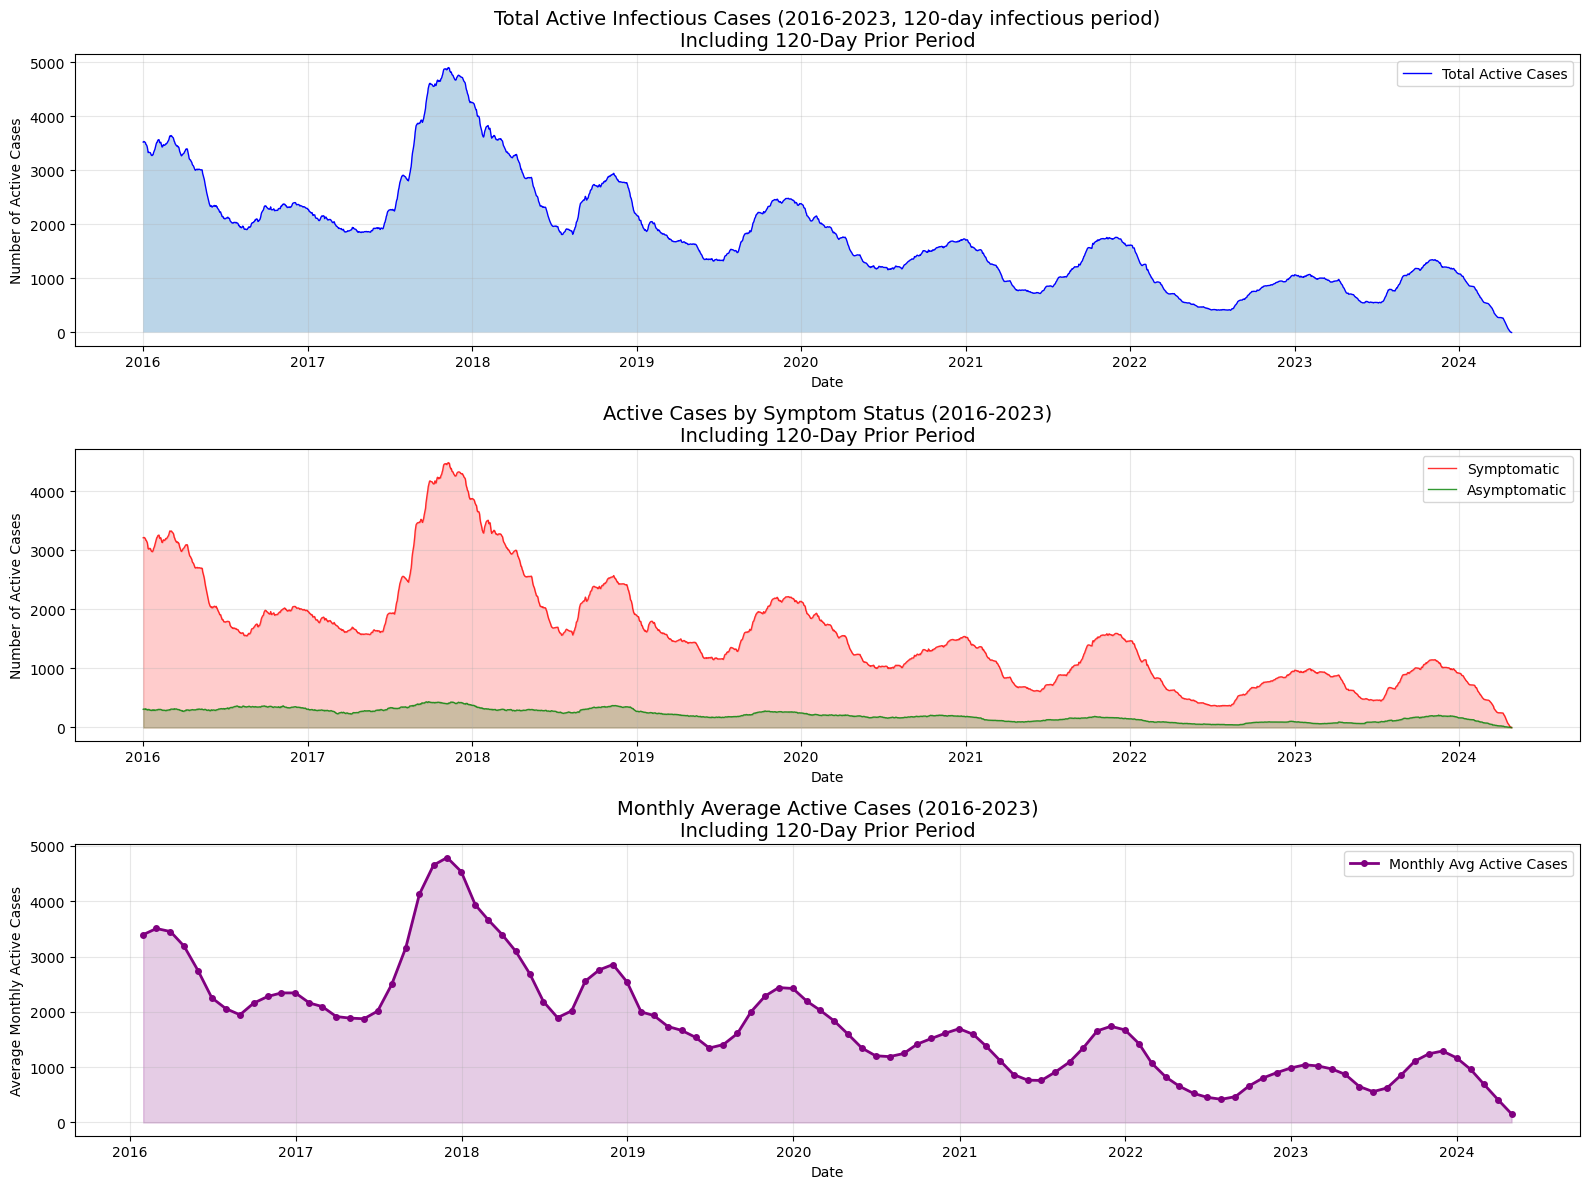

In [14]:
# Plot the results
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Total active cases
axes[0].plot(daily_active_cases_2016_2023_with_prior['date'], 
             daily_active_cases_2016_2023_with_prior['active_total'], 
             color='blue', linewidth=1, label='Total Active Cases')
axes[0].fill_between(daily_active_cases_2016_2023_with_prior['date'], 0, 
                     daily_active_cases_2016_2023_with_prior['active_total'], alpha=0.3)
axes[0].set_title('Total Active Infectious Cases (2016-2023, 120-day infectious period)\nIncluding 120-Day Prior Period', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Active Cases')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Symptomatic vs Asymptomatic
axes[1].plot(daily_active_cases_2016_2023_with_prior['date'], 
             daily_active_cases_2016_2023_with_prior['active_symptomatic'], 
             color='red', linewidth=1, label='Symptomatic', alpha=0.8)
axes[1].plot(daily_active_cases_2016_2023_with_prior['date'], 
             daily_active_cases_2016_2023_with_prior['active_asymptomatic'], 
             color='green', linewidth=1, label='Asymptomatic', alpha=0.8)
axes[1].fill_between(daily_active_cases_2016_2023_with_prior['date'], 0, 
                     daily_active_cases_2016_2023_with_prior['active_symptomatic'], 
                     color='red', alpha=0.2)
axes[1].fill_between(daily_active_cases_2016_2023_with_prior['date'], 0, 
                     daily_active_cases_2016_2023_with_prior['active_asymptomatic'], 
                     color='green', alpha=0.2)
axes[1].set_title('Active Cases by Symptom Status (2016-2023)\nIncluding 120-Day Prior Period', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Active Cases')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: Monthly averages
# Resample to monthly for smoother view
monthly_avg = daily_active_cases_2016_2023_with_prior.set_index('date').resample('M').mean()

axes[2].plot(monthly_avg.index, monthly_avg['active_total'], 
             color='purple', linewidth=2, marker='o', markersize=4, label='Monthly Avg Active Cases')
axes[2].fill_between(monthly_avg.index, 0, monthly_avg['active_total'], alpha=0.2, color='purple')
axes[2].set_title('Monthly Average Active Cases (2016-2023)\nIncluding 120-Day Prior Period', fontsize=14)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Average Monthly Active Cases')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()